<a href="https://colab.research.google.com/github/Alex-Marin21/ColabImageUtils/blob/main/ImageModification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Yasuo_0.jpg to Yasuo_0.jpg


In [ ]:
import os
os.listdir('/content')


['.config', 'Yasuo_0.jpg', 'dataset_laborator_1.xlsx', 'sample_data']

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
import torchvision.transforms as transforms
import random

Dimensiuni: (717, 1215, 3)


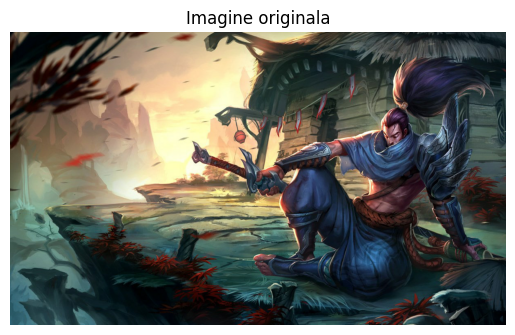

In [ ]:

img = cv2.imread('Yasuo_0.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Dimensiuni:", img.shape)

plt.imshow(img_rgb)
plt.title("Imagine originala")
plt.axis('off')
plt.show()


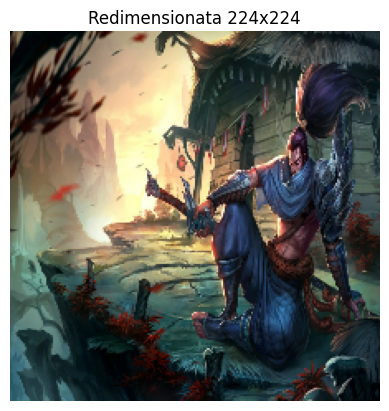

In [ ]:
img_resized = cv2.resize(img_rgb, (224, 224))
plt.imshow(img_resized)
plt.title("Redimensionata 224x224")
plt.axis('off')
plt.show()


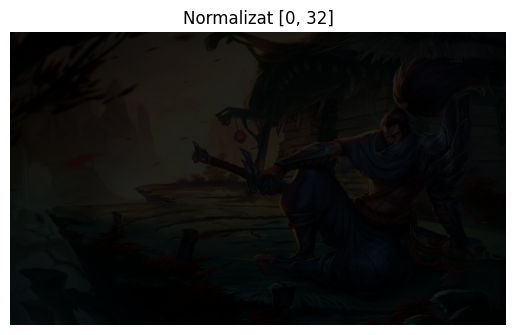

In [ ]:
img_scaled = (img_rgb / 255.0) * 32
img_scaled = img_scaled.astype(np.uint8)

plt.imshow(img_scaled)
plt.title("Normalizat [0, 32]")
plt.axis('off')
plt.show()


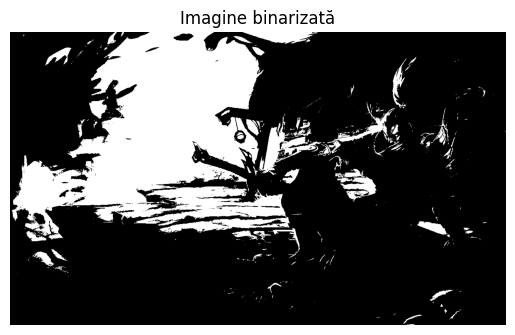

In [ ]:
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
_, binary = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY)

plt.imshow(binary, cmap='gray')
plt.title("Imagine binarizată")
plt.axis('off')
plt.show()


Unghiul ales: -4.11


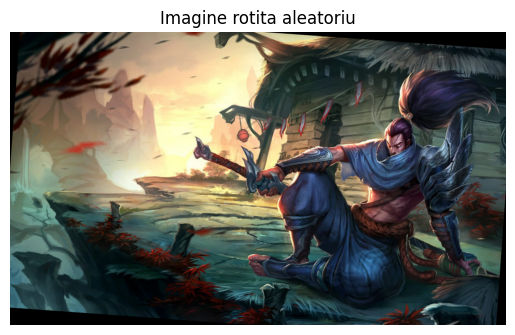

In [ ]:
def random_rotation(img, angle_range=15):
    angle = random.uniform(-angle_range, angle_range)
    print(f"Unghiul ales: {angle:.2f}")
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    rotated = cv2.warpAffine(img, M, (w, h))
    return rotated

img_rotated = random_rotation(img_rgb)

plt.imshow(img_rotated)
plt.title("Imagine rotita aleatoriu")
plt.axis('off')
plt.show()


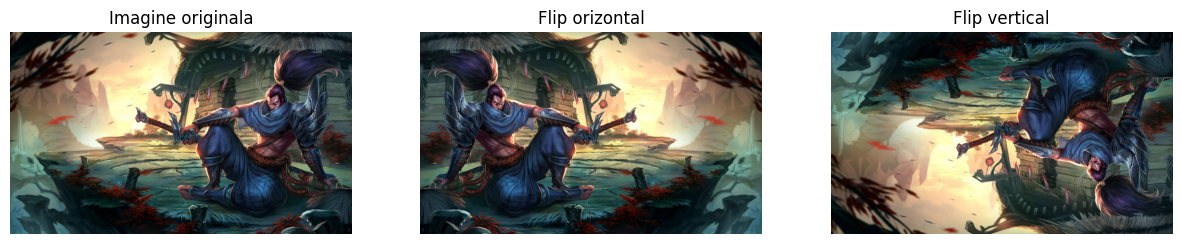

In [ ]:
img_flip_horizontal = cv2.flip(img_rgb, 1)

img_flip_vertical = cv2.flip(img_rgb, 0)

fig, axs = plt.subplots(1, 3, figsize=(15,5))

axs[0].imshow(img_rgb)
axs[0].set_title("Imagine originala")
axs[0].axis('off')

axs[1].imshow(img_flip_horizontal)
axs[1].set_title("Flip orizontal")
axs[1].axis('off')

axs[2].imshow(img_flip_vertical)
axs[2].set_title("Flip vertical")
axs[2].axis('off')

plt.show()

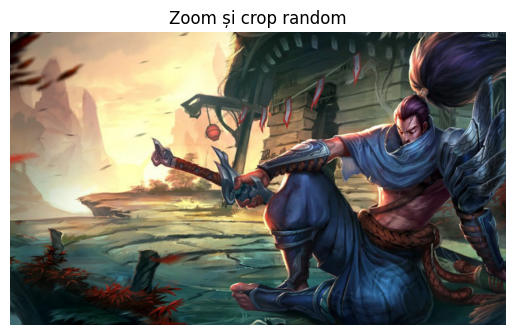

In [ ]:
def random_zoom_crop_original(img, zoom_range=(1.0, 1.5), crop_size=(717, 1215)):
    h, w = img.shape[:2]

    zoom_factor = random.uniform(zoom_range[0], zoom_range[1])

    zoomed_img = cv2.resize(img, None, fx=zoom_factor, fy=zoom_factor, interpolation=cv2.INTER_LINEAR)

    zh, zw = zoomed_img.shape[:2]

    if zh < crop_size[0] or zw < crop_size[1]:
        raise ValueError("Zoom insuficient")

    top = random.randint(0, zh - crop_size[0])
    left = random.randint(0, zw - crop_size[1])

    cropped_img = zoomed_img[top:top + crop_size[0], left:left + crop_size[1]]

    return cropped_img

img_zoom_crop = random_zoom_crop_original(img_rgb, zoom_range=(1.0, 1.5), crop_size=img_rgb.shape[:2])

plt.imshow(img_zoom_crop)
plt.title("Zoom și crop random")
plt.axis('off')
plt.show()


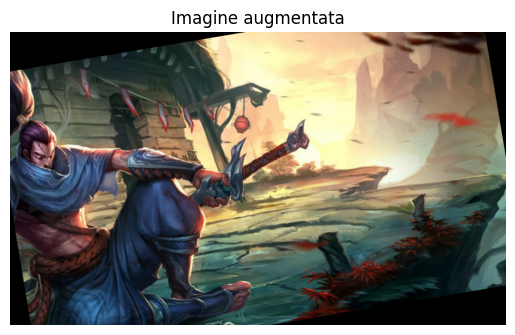

In [ ]:
def augment_image(img):
    h, w = img.shape[:2]
    zoom_factor = random.uniform(1.0, 1.5)
    zoomed_img = cv2.resize(img, None, fx=zoom_factor, fy=zoom_factor, interpolation=cv2.INTER_LINEAR)
    zh, zw = zoomed_img.shape[:2]
    top = random.randint(0, zh - h)
    left = random.randint(0, zw - w)
    cropped_img = zoomed_img[top:top + h, left:left + w]

    if random.random() > 0.5:
        cropped_img = cv2.flip(cropped_img, 1)

    angle = random.uniform(-15, 15)
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated_img = cv2.warpAffine(cropped_img, M, (w, h))

    return rotated_img

img_augmented = augment_image(img_rgb)

import matplotlib.pyplot as plt

plt.imshow(img_augmented)
plt.title("Imagine augmentata")
plt.axis('off')
plt.show()

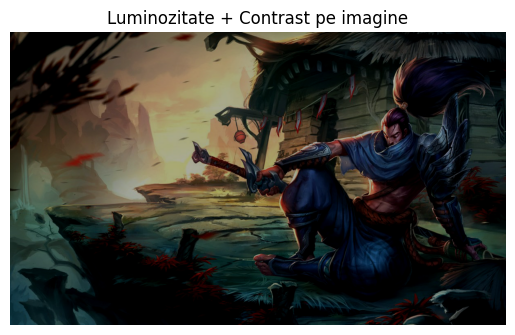

In [ ]:
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt

img_pil = Image.fromarray(img_rgb)

enhancer_brightness = ImageEnhance.Brightness(img_pil)
img_bright = enhancer_brightness.enhance(0.5)

enhancer_contrast = ImageEnhance.Contrast(img_bright)
img_final = enhancer_contrast.enhance(1.5)

plt.imshow(img_final)
plt.title("Luminozitate + Contrast pe imagine")
plt.axis('off')
plt.show()


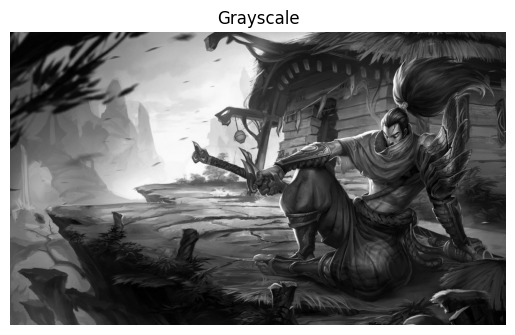

In [ ]:
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')
plt.show()


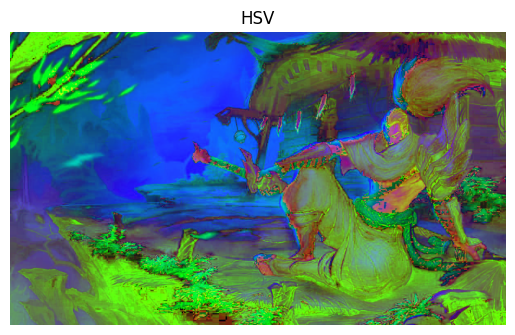

In [ ]:
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

plt.imshow(img_hsv)
plt.title("HSV")
plt.axis('off')
plt.show()